# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2680s 16us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

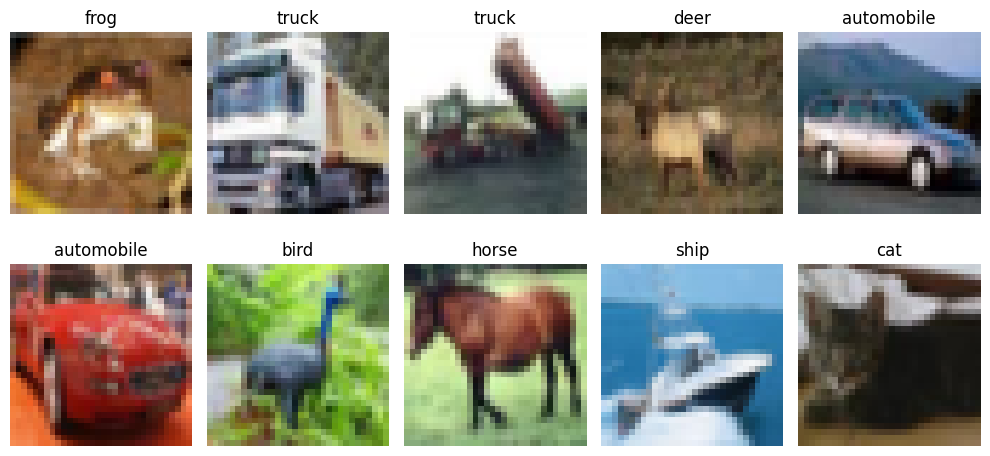

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.2608 - loss: 2.0063 - val_accuracy: 0.3412 - val_loss: 1.8294
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3074 - loss: 1.8856 - val_accuracy: 0.3428 - val_loss: 1.8080
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3248 - loss: 1.8450 - val_accuracy: 0.3692 - val_loss: 1.7845
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.3390 - loss: 1.8077 - val_accuracy: 0.3848 - val_loss: 1.7381
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3476 - loss: 1.7826 - val_accuracy: 0.3790 - val_loss: 1.7497
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3557 - loss: 1.7639 - val_accuracy: 0.4000 - val_loss: 1.7000
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3678 - loss: 1.7425 - val_accuracy: 0.3716 - val_loss: 1.7503
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3665 - loss: 1.7359 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4174 - loss: 1.6553
ANN Test Accuracy: 0.4174000024795532


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 111ms/step - accuracy: 0.4740 - loss: 1.4771 - val_accuracy: 0.5500 - val_loss: 1.2641
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 110ms/step - accuracy: 0.6076 - loss: 1.1254 - val_accuracy: 0.6130 - val_loss: 1.1053
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 109ms/step - accuracy: 0.6682 - loss: 0.9627 - val_accuracy: 0.6196 - val_loss: 1.0701
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 110ms/step - accuracy: 0.7058 - loss: 0.8381 - val_accuracy: 0.7010 - val_loss: 0.8686
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 111ms/step - accuracy: 0.7356 - loss: 0.7576 - val_accuracy: 0.6422 - val_loss: 1.1500
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 111ms/step - accuracy: 0.7638 - loss: 0.6689 - val_accuracy: 0.6836 - val_loss: 0.9224
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 110ms/step - accuracy: 0.7850 - loss: 0.6019 - val_accuracy: 0.7338 - val_loss: 0.8239
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 111ms/step - accuracy: 0.8084 - loss: 0

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6416 - loss: 1.2859
CNN Test Accuracy: 0.6416000127792358


## 📈 Compare Learning Curves

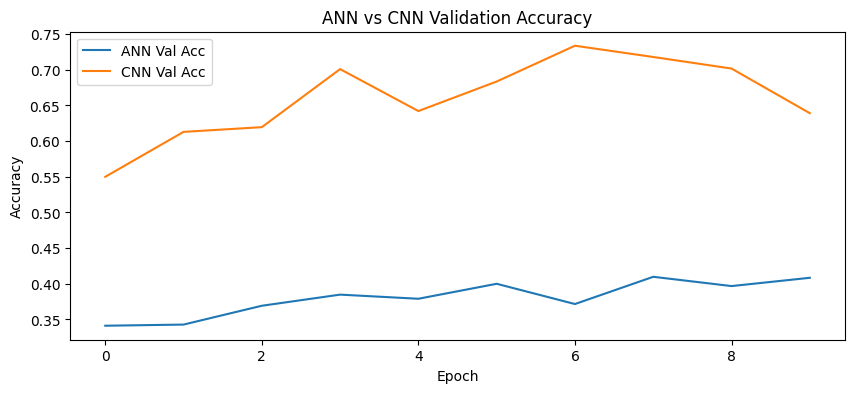

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4174
1,CNN,0.6416


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

##  Solutions to Student Learning Tasks
Below are the implementations for the 5 student learning tasks:
1. Increased ANN layers and configuration.
2. Spatial CNN filters scaled from 32 → 64 → 128.
3. Training expanded to 20 epochs.
4. Integration of EarlyStopping callback.
5. Training of the data-augmented CNN model.

In [ ]:
#  Upgraded ANN model with extra layers and EarlyStopping for 20 epochs
upgraded_ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

upgraded_ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define EarlyStopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Training Upgraded ANN model...")
upgraded_ann_history = upgraded_ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping]
)

upgraded_ann_test_loss, upgraded_ann_test_acc = upgraded_ann_model.evaluate(x_test_flat, y_test)
print("Upgraded ANN Test Accuracy:", upgraded_ann_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Upgraded ANN model...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 61ms/step - accuracy: 0.2511 - loss: 2.0189 - val_accuracy: 0.3234 - val_loss: 1.8718
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 59ms/step - accuracy: 0.3051 - loss: 1.8878 - val_accuracy: 0.3504 - val_loss: 1.8255
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.3225 - loss: 1.8479 - val_accuracy: 0.3532 - val_loss: 1.8103
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.3376 - loss: 1.8131 - val_accuracy: 0.3742 - val_loss: 1.7615
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.3474 - loss: 1.7924 - val_accuracy: 0.3874 - val_loss: 1.7069
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.3572 - loss: 1.7685 - val_accuracy: 0.3876 - val_loss: 1.7175
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.3634 - loss: 1.7551 - val_accuracy: 0.3794 - val_loss: 1.7624
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 59ms/step - acc

In [ ]:
#  Upgraded Data Augmented CNN model with filters 32->64->128, EarlyStopping, trained for 20 epochs
upgraded_data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

upgraded_aug_cnn_model = models.Sequential([
    upgraded_data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

upgraded_aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Upgraded Data-Augmented CNN model...")
upgraded_aug_history = upgraded_aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping]
)

upgraded_aug_test_loss, upgraded_aug_test_acc = upgraded_aug_cnn_model.evaluate(x_test_norm, y_test)
print("Upgraded Augmented CNN Test Accuracy:", upgraded_aug_test_acc)

Training Upgraded Data-Augmented CNN model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 129ms/step - accuracy: 0.4165 - loss: 1.6455 - val_accuracy: 0.4706 - val_loss: 1.4872
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 128ms/step - accuracy: 0.5148 - loss: 1.3634 - val_accuracy: 0.5328 - val_loss: 1.3497
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 127ms/step - accuracy: 0.5542 - loss: 1.2566 - val_accuracy: 0.5582 - val_loss: 1.2705
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 127ms/step - accuracy: 0.5878 - loss: 1.1749 - val_accuracy: 0.5866 - val_loss: 1.2762
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.6096 - loss: 1.1125 - val_accuracy: 0.6322 - val_loss: 1.0568
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.6255 - loss: 1.0700 - val_accuracy: 0.6598 - val_loss: 0.9738
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 128ms/step - accuracy: 0.6457 - loss: 1.0095 - val_accuracy: 0.6776 - val_loss: 0.9278
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 128ms/step - accuracy: 0.6538 - lo

###  Validation Learning Curves Comparison
Let's compare the validation accuracy of the upgraded ANN and augmented CNN models over training.

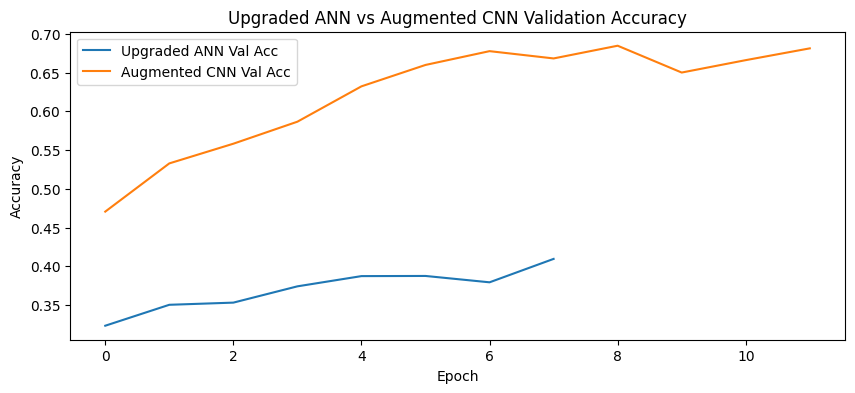

In [14]:
plt.figure(figsize=(10,4))
plt.plot(upgraded_ann_history.history['val_accuracy'], label='Upgraded ANN Val Acc')
plt.plot(upgraded_aug_history.history['val_accuracy'], label='Augmented CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Upgraded ANN vs Augmented CNN Validation Accuracy")
plt.legend()
plt.show()

###  Final Accuracy Comparison (All Models)
Here is the final comparison table displaying the test accuracy scores for all four model variations:

In [15]:
final_comparison = pd.DataFrame({
    "Model": [
        "Baseline ANN (10 epochs)",
        "Baseline CNN (10 epochs)",
        "Upgraded ANN (20 epochs + ES)",
        "Augmented CNN (32->64->128, 20 epochs + ES)"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        upgraded_ann_test_acc,
        upgraded_aug_test_acc
    ]
})
final_comparison

,Model,Test Accuracy
0,Baseline ANN (10 epochs),0.4174
1,Baseline CNN (10 epochs),0.6416
2,Upgraded ANN (20 epochs + ES),0.3973
3,"Augmented CNN (32->64->128, 20 epochs + ES)",0.6899


#  Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**